In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import matplotlib.pyplot as plt

In [5]:
data_sources = {
    "10066": r"C:\Users\ASPIRE A715 - 42G\Downloads\MentalHealth_AI_Project\Data\raw\VMHQA\csv\[SHARING]_final_full_10066.csv", 
    "18082024-csv": r"C:\Users\ASPIRE A715 - 42G\Downloads\MentalHealth_AI_Project\Data\raw\VMHQA\csv\[SHARING]_FinalData_10000_18082024.csv",
}

In [3]:
def analyze_sample(name, path):
    print(f"\n--- Đang phân tích tập dữ liệu: {name} ---")
    
    if not os.path.exists(path):
        print(f"Lỗi: Không tìm thấy file tại {path}")
        return

    try:
        if path.endswith('.csv'):
            df = pd.read_csv(path)
        else:
            df = pd.read_excel(path, engine='openpyxl')
        print(f"Tổng số bản ghi: {len(df)}")
        print(f"Các cột dữ liệu: {df.columns.tolist()}")
        print(f"Số lượng topic: {len(df['Topic'].value_counts())}")
        # Kiểm tra dữ liệu thiếu
        missing = df.isnull().sum().sum()
        print(f"Tổng số ô trống (null): {missing}")
        # top_10 = df.head(10)
        # return top_10
    except Exception as e:
        print(f"Lỗi khi đọc file {name}: {e}")
        return None

In [6]:
dfs = {}
for name, path in data_sources.items():
    df_result = analyze_sample(name, path)
    if df_result is not None:
        dfs[name] = df_result
        print(f"Hiển thị 10 dòng đầu tiên của {name}:")
        print(df_result) 


--- Đang phân tích tập dữ liệu: 10066 ---
Tổng số bản ghi: 10066
Các cột dữ liệu: ['ID', 'Topic', 'Question', 'Answer', 'A', 'B', 'C', 'D', 'Paragraph 1', 'Paragraph 2', 'Paragraph 3', 'Fact 1', 'Fact 2', 'Fact 3', 'Question_Type', 'Reference']
Số lượng topic: 1543
Tổng số ô trống (null): 0

--- Đang phân tích tập dữ liệu: 18082024-csv ---
Tổng số bản ghi: 10000
Các cột dữ liệu: ['Topic', 'Question', 'Answer', 'A', 'B', 'C', 'D', 'Paragraph 1', 'Paragraph 2', 'Paragraph 3', 'Fact 1', 'Fact 2', 'Fact 3', 'Question_Type', 'Reference', 'ID']
Số lượng topic: 1534
Tổng số ô trống (null): 0


In [7]:
def convert_csv_to_xlsx(csv_input, xlsx_output):
    try:
        # 1. Đọc dữ liệu từ CSV
        print(f"Đang đọc dữ liệu từ: {csv_input}")
        df = pd.read_csv(csv_input)

        # 2. Xuất ra file Excel bằng Engine openpyxl
        writer = pd.ExcelWriter(xlsx_output, engine='openpyxl')
        df.to_excel(writer, index=False, sheet_name='VMHQA_Data')
        
        # 3. Tự động căn chỉnh độ rộng cột (Đoạn này giúp file dễ xem hơn)
        workbook  = writer.book
        worksheet = writer.sheets['VMHQA_Data']

        for i, col in enumerate(df.columns):
            # Tính toán độ dài của tiêu đề hoặc giá trị dài nhất trong cột (giới hạn tối đa 50)
            column_len = max(df[col].astype(str).map(len).max(), len(col)) + 2
            column_len = min(column_len, 50) 
            
            # Thiết lập độ rộng cột trong Excel (cột A tương ứng i=1)
            worksheet.column_dimensions[chr(65 + i)].width = column_len

        writer.close()
        print(f"--- Chuyển đổi thành công! ---")
        print(f"File mới tại: {xlsx_output}")

    except Exception as e:
        print(f"Có lỗi xảy ra: {e}")

In [8]:
for name, path in data_sources.items():
    if path.endswith('.csv'):
        convert_csv_to_xlsx(path, path.replace('.csv', '.xlsx'))

Đang đọc dữ liệu từ: C:\Users\ASPIRE A715 - 42G\Downloads\MentalHealth_AI_Project\Data\raw\VMHQA\csv\[SHARING]_final_full_10066.csv
--- Chuyển đổi thành công! ---
File mới tại: C:\Users\ASPIRE A715 - 42G\Downloads\MentalHealth_AI_Project\Data\raw\VMHQA\csv\[SHARING]_final_full_10066.xlsx
Đang đọc dữ liệu từ: C:\Users\ASPIRE A715 - 42G\Downloads\MentalHealth_AI_Project\Data\raw\VMHQA\csv\[SHARING]_FinalData_10000_18082024.csv
--- Chuyển đổi thành công! ---
File mới tại: C:\Users\ASPIRE A715 - 42G\Downloads\MentalHealth_AI_Project\Data\raw\VMHQA\csv\[SHARING]_FinalData_10000_18082024.xlsx


In [25]:
def deep_analysis(df):
    print("--- BẮT ĐẦU PHÂN TÍCH CHUYÊN SÂU ---")
    
    # 1. Thống kê theo Topic
    if 'Topic' in df.columns:
        topic_counts = df['Topic'].value_counts()
        print("\nSố lượng theo chủ đề:\n", topic_counts)
        
        plt.figure(figsize=(10,6))
        topic_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140)
        plt.title('Tỷ lệ các chủ đề tâm thần học trong VMHQA')
        plt.ylabel('')
        plt.show()

    # 2. Phân tích độ dài văn bản (Số lượng từ)
    q_col = 'Question' 
    if q_col in df.columns:
        df['q_length'] = df[q_col].apply(lambda x: len(str(x).split()))
        print(f"\nĐộ dài câu hỏi trung bình: {df['q_length'].mean():.2f} từ")
        print(f"Câu hỏi dài nhất: {df['q_length'].max()} từ")

    # 3. Kiểm tra sự cân bằng đáp án
    if 'Answer' in df.columns:
        ans_counts = df['Answer'].value_counts().sort_index()
        plt.figure(figsize=(8,5))
        sns.barplot(x=ans_counts.index, y=ans_counts.values, palette='viridis')
        plt.title('Phân phối các đáp án đúng (A/B/C/D)')
        plt.show()

    # 4. Kiểm tra dữ liệu Fact/Paragraph (Độ phủ thông tin)
    fact_cols = [c for c in df.columns if 'Fact' in c or 'Paragraph' in c]
    for col in fact_cols:
        null_count = df[col].isnull().sum()
        print(f"Cột {col}: Có {len(df) - null_count} mẫu dữ liệu hỗ trợ.")


--- Phân tích chuyên sâu cho 10066 ---

--- Đang phân tích tập dữ liệu: 10066 ---
Tổng số bản ghi: 10066
Các cột dữ liệu: ['ID', 'Topic', 'Question', 'Answer', 'A', 'B', 'C', 'D', 'Paragraph 1', 'Paragraph 2', 'Paragraph 3', 'Fact 1', 'Fact 2', 'Fact 3', 'Question_Type', 'Reference']
Số lượng topic: 1543
Tổng số ô trống (null): 0
--- BẮT ĐẦU PHÂN TÍCH CHUYÊN SÂU ---

Số lượng theo chủ đề:
 Topic
Thực phẩm tốt cho người trầm cảm          305
Nghiện mạng xã hội                        238
Phòng ngừa tự tử                          220
Ma túy đá                                 210
Quản lí căng thẳng                        200
                                         ... 
Trầm cảm không điển hình                    1
Cơn tức giận ái kỷ (Narcissistic Rage)      1
Liệu pháp tương tác cá nhân (IPT)          1
Bệnh trầm cảm sau sinh kéo dài bao lâu      1
Rối loạn tiền đình ngoại biên               1
Name: count, Length: 1543, dtype: int64


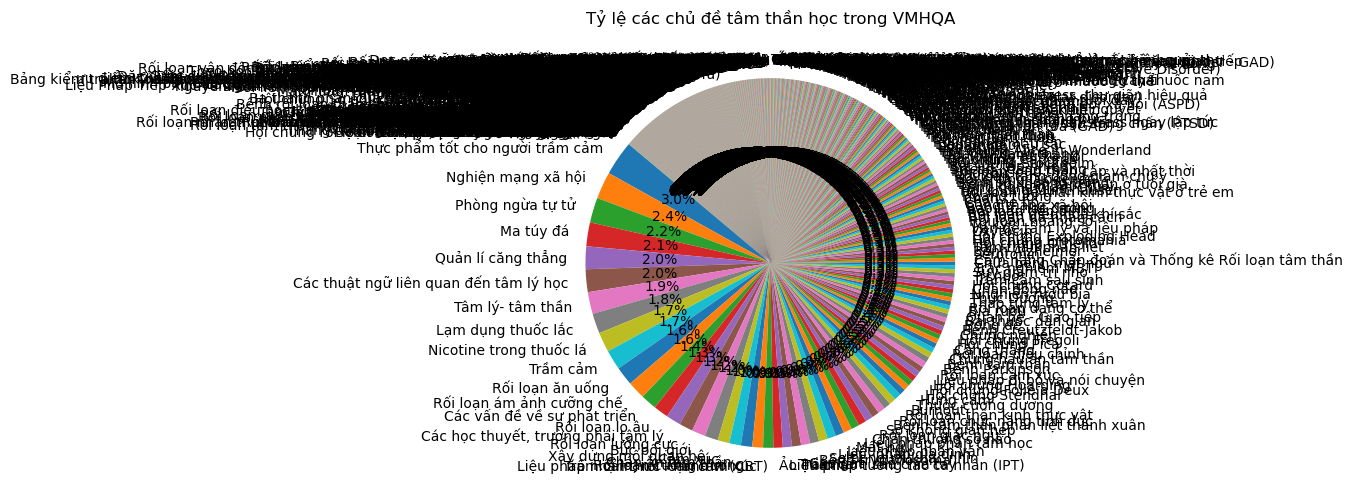


Độ dài câu hỏi trung bình: 24.67 từ
Câu hỏi dài nhất: 1100 từ


C:\Users\ASPIRE A715 - 42G\AppData\Local\Temp\ipykernel_632\3430221218.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ans_counts.index, y=ans_counts.values, palette='viridis')


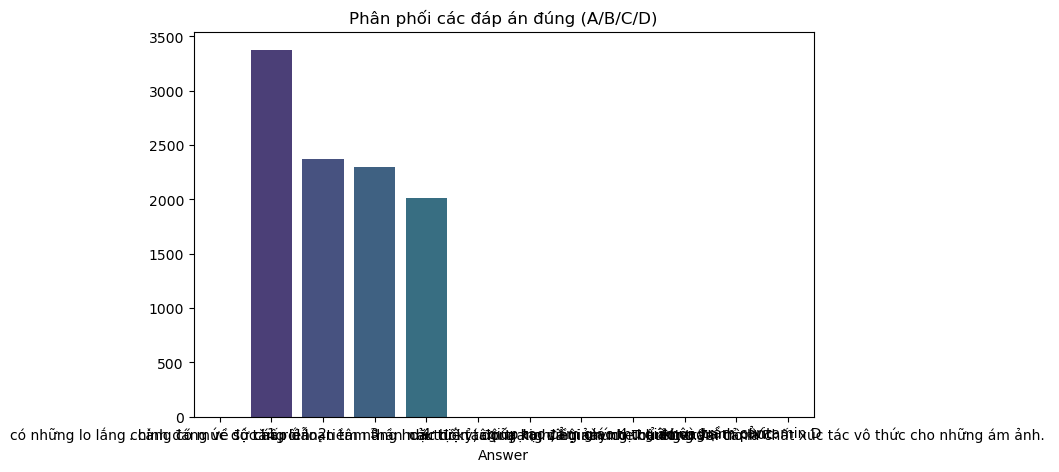

Cột Paragraph 1: Có 10066 mẫu dữ liệu hỗ trợ.
Cột Paragraph 2: Có 10066 mẫu dữ liệu hỗ trợ.
Cột Paragraph 3: Có 10066 mẫu dữ liệu hỗ trợ.
Cột Fact 1: Có 10066 mẫu dữ liệu hỗ trợ.
Cột Fact 2: Có 10066 mẫu dữ liệu hỗ trợ.
Cột Fact 3: Có 10066 mẫu dữ liệu hỗ trợ.

--- Phân tích chuyên sâu cho 18082024-xlsx ---

--- Đang phân tích tập dữ liệu: 18082024-xlsx ---
Tổng số bản ghi: 10000
Các cột dữ liệu: ['Topic', 'Question', 'Answer', 'A', 'B', 'C', 'D', 'Paragraph 1', 'Paragraph 2', 'Paragraph 3', 'Fact 1', 'Fact 2', 'Fact 3', 'Question_Type', 'Reference', 'ID']
Số lượng topic: 1534
Tổng số ô trống (null): 0
--- BẮT ĐẦU PHÂN TÍCH CHUYÊN SÂU ---

Số lượng theo chủ đề:
 Topic
Thực phẩm tốt cho người trầm cảm                                       297
Nghiện mạng xã hội                                                     237
Phòng ngừa tự tử                                                       220
Ma túy đá                                                              209
Quản lí căng thẳng     

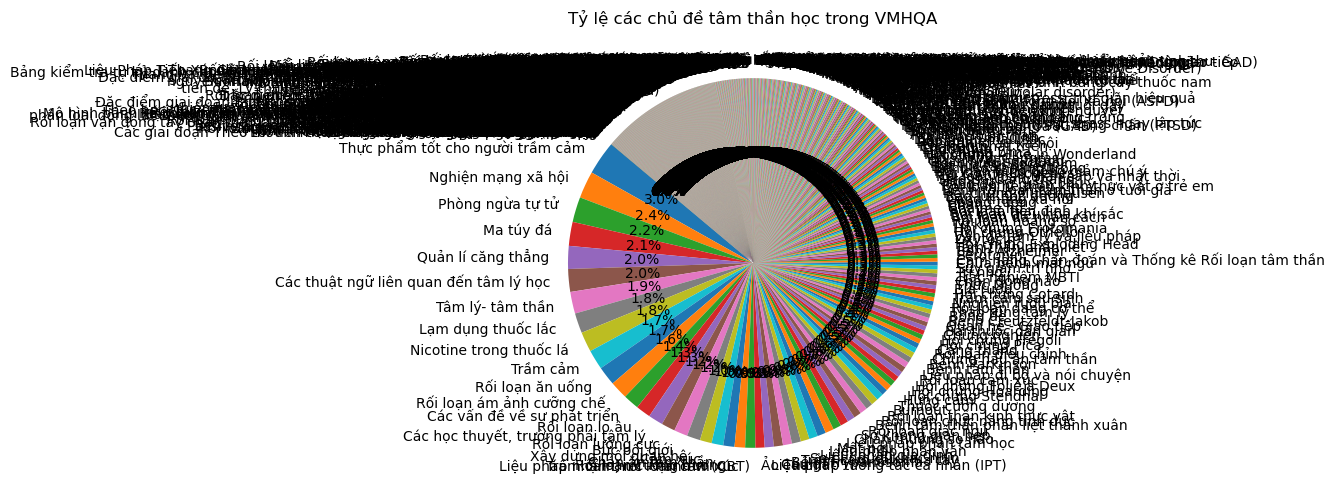


Độ dài câu hỏi trung bình: 24.64 từ
Câu hỏi dài nhất: 1100 từ


C:\Users\ASPIRE A715 - 42G\AppData\Local\Temp\ipykernel_632\3430221218.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ans_counts.index, y=ans_counts.values, palette='viridis')


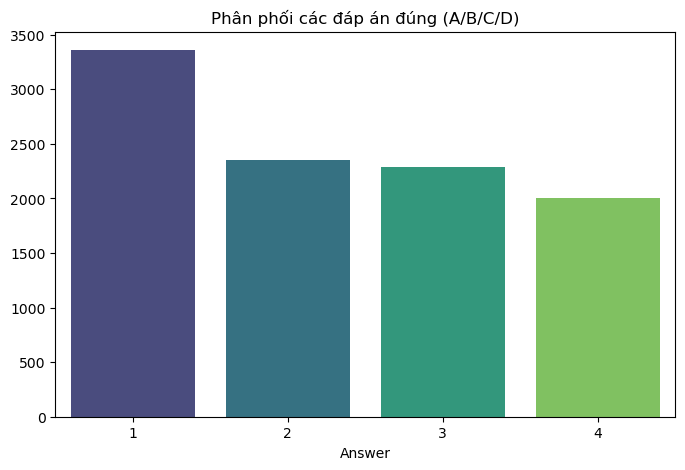

Cột Paragraph 1: Có 10000 mẫu dữ liệu hỗ trợ.
Cột Paragraph 2: Có 10000 mẫu dữ liệu hỗ trợ.
Cột Paragraph 3: Có 10000 mẫu dữ liệu hỗ trợ.
Cột Fact 1: Có 10000 mẫu dữ liệu hỗ trợ.
Cột Fact 2: Có 10000 mẫu dữ liệu hỗ trợ.
Cột Fact 3: Có 10000 mẫu dữ liệu hỗ trợ.

--- Phân tích chuyên sâu cho 18082024-csv ---

--- Đang phân tích tập dữ liệu: 18082024-csv ---
Tổng số bản ghi: 10000
Các cột dữ liệu: ['Topic', 'Question', 'Answer', 'A', 'B', 'C', 'D', 'Paragraph 1', 'Paragraph 2', 'Paragraph 3', 'Fact 1', 'Fact 2', 'Fact 3', 'Question_Type', 'Reference', 'ID']
Số lượng topic: 1534
Tổng số ô trống (null): 0
--- BẮT ĐẦU PHÂN TÍCH CHUYÊN SÂU ---

Số lượng theo chủ đề:
 Topic
Thực phẩm tốt cho người trầm cảm                                       297
Nghiện mạng xã hội                                                     237
Phòng ngừa tự tử                                                       220
Ma túy đá                                                              209
Quản lí căng thẳng       

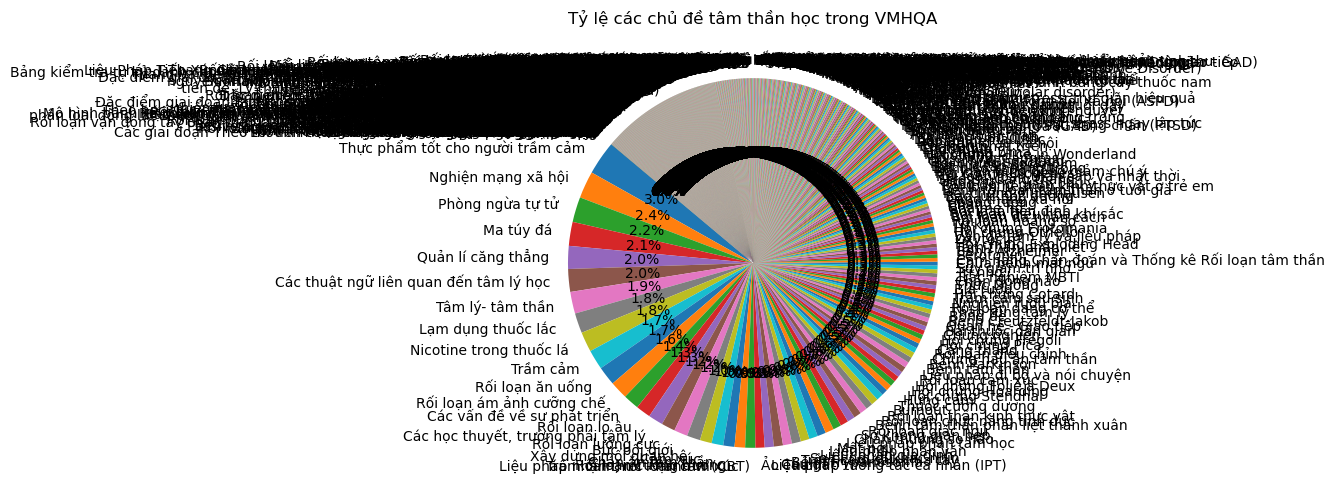


Độ dài câu hỏi trung bình: 24.64 từ
Câu hỏi dài nhất: 1100 từ


C:\Users\ASPIRE A715 - 42G\AppData\Local\Temp\ipykernel_632\3430221218.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ans_counts.index, y=ans_counts.values, palette='viridis')


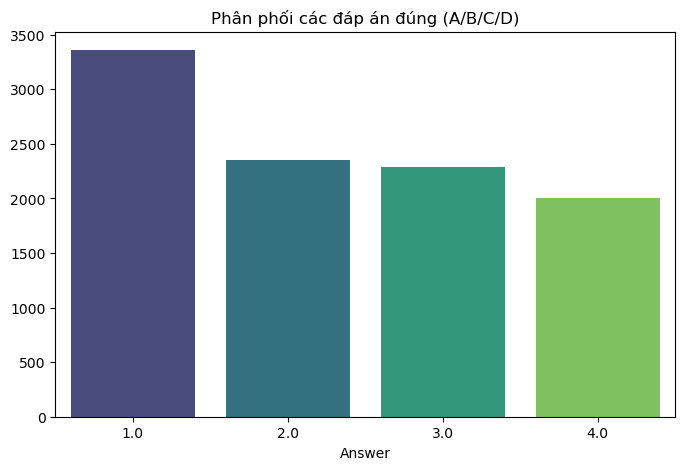

Cột Paragraph 1: Có 10000 mẫu dữ liệu hỗ trợ.
Cột Paragraph 2: Có 10000 mẫu dữ liệu hỗ trợ.
Cột Paragraph 3: Có 10000 mẫu dữ liệu hỗ trợ.
Cột Fact 1: Có 10000 mẫu dữ liệu hỗ trợ.
Cột Fact 2: Có 10000 mẫu dữ liệu hỗ trợ.
Cột Fact 3: Có 10000 mẫu dữ liệu hỗ trợ.


In [33]:
for name, path in data_sources.items():
    print(f"\n--- Phân tích chuyên sâu cho {name} ---")
    analyze_sample(name, path)
    if path.endswith('.csv'):
            df = pd.read_csv(path)
    else:
        df = pd.read_excel(path, engine='openpyxl')

    deep_analysis(df)